In [ ]:
import emit_utils

In [ ]:
#output = emit_utils.get_plume_granule_ids(gas_type="both")

In [ ]:
output = emit_utils.display_plume_previews('20220827T074030', gas_type="both")

In [ ]:
emit_utils.display_browse_with_polygons('20220827T074030', gas_type="both")

In [ ]:
emit_utils.display_browse_panels('20220827T074030', gas_type="both")

In [ ]:
"""
Step F: Run one granule through save_one_granule_to_dataset and verify
difficulty metrics in plume_metadata.json and dataset_index.csv.

Requires: Earthdata login, network, disk for downloads, same env as emit_utils.
"""
import json
import os
import tempfile

import numpy as np
import pandas as pd

# Adjust import path if needed
from emit_utils import save_one_granule_to_dataset, get_plume_granule_ids

DIFFICULTY_KEYS = (
    "max_signal_to_uncertainty",
    "mean_plume_sensitivity",
    "plume_pixel_area",
    "background_std_dev",
)


def verify_plume_metadata_json(path: str) -> dict:
    with open(path, "r") as f:
        meta = json.load(f)
    missing = [k for k in DIFFICULTY_KEYS if k not in meta]
    if missing:
        print(f"  MISSING keys in {path}: {missing}")
    else:
        print(f"  OK: all four difficulty keys present in {os.path.basename(path)}")
    for k in DIFFICULTY_KEYS:
        v = meta.get(k, None)
        print(f"    {k}: {v!r}")
    return meta


def sanity_check_metrics(meta: dict) -> None:
    """Loose checks — adjust bounds to your data."""
    gp = meta.get("plume_pixel_area")
    if gp is not None and not (gp is None or (isinstance(gp, float) and np.isnan(gp))):
        if gp < 0:
            print("  WARN: plume_pixel_area < 0")
        if gp == 0:
            print("  WARN: plume_pixel_area == 0 (no plume pixels in aligned mask?)")

    rc = meta.get("max_signal_to_uncertainty")
    if rc is not None and isinstance(rc, (int, float)) and np.isfinite(rc):
        if rc < 0:
            print("  WARN: max_signal_to_uncertainty < 0 (unusual)")


def run_step_f(
    granule_id: str | None = None,
    gas_type: str = "ch4",
    dataset_dir: str | None = None,
    overwrite: bool = True,
):
    """
    If granule_id is None, fetches one recent CH4 plume granule ID from Earthdata.
    """
    if granule_id is None:
        ids = get_plume_granule_ids(gas_type=gas_type, max_count=5)
        if not ids:
            raise RuntimeError("No granule IDs returned — check Earthdata login / search.")
        granule_id = ids[0]
        print(f"Using granule_id = {granule_id!r} (first from get_plume_granule_ids)")

    if dataset_dir is None:
        dataset_dir = tempfile.mkdtemp(prefix="emit_step_f_")
        print(f"dataset_dir = {dataset_dir!r}")

    df = save_one_granule_to_dataset(
        granule_id,
        dataset_dir,
        overwrite=overwrite,
        gas_type=gas_type,
    )
    if df is None:
        print("save_one_granule_to_dataset returned None (skip or failure).")
        return

    # Resolve granule folder (single vs multiple plumes)
    candidates = [
        os.path.join(dataset_dir, f"{granule_id}_{gas_type}"),
        os.path.join(dataset_dir, f"{granule_id}_{gas_type}_multiple_plumes"),
    ]
    granule_root = next((p for p in candidates if os.path.isdir(p)), None)
    if granule_root is None:
        print("Could not find granule output directory.")
        return

    print(f"\nScanning plume_metadata.json under: {granule_root}")
    for root, _, files in os.walk(granule_root):
        if "plume_metadata.json" not in files:
            continue
        path = os.path.join(root, "plume_metadata.json")
        print(f"\n--- {path} ---")
        meta = verify_plume_metadata_json(path)
        sanity_check_metrics(meta)

    # dataset_index.csv from returned DataFrame
    print("\n--- index DataFrame (positive rows) ---")
    pos = df[df["label"] == "positive"]
    print(pos[["id", "granule_id", "plume_id"] + list(DIFFICULTY_KEYS)].to_string())
    for k in DIFFICULTY_KEYS:
        if k not in pos.columns:
            print(f"WARN: column {k!r} missing from index DataFrame")

    csv_path = os.path.join(dataset_dir, "dataset_index.csv")
    if os.path.isfile(csv_path):
        full = pd.read_csv(csv_path)
        print("\n--- dataset_index.csv (last few rows) ---")
        print(full.tail().to_string())


run_step_f(granule_id=None, gas_type="ch4", overwrite=True)

In [ ]:
# --- Sample test: one granule → dataset, verify metadata, export one chip bundle ---
import json
import os
import shutil

import earthaccess

import emit_utils

# Output: one folder you can zip or commit (add to .gitignore if large)
EXPORT_ROOT = os.path.abspath(
    os.path.join(os.path.dirname(emit_utils.__file__), "sample_chip_export")
)
DATASET_DIR = os.path.join(EXPORT_ROOT, "_full_granule_build")
os.makedirs(EXPORT_ROOT, exist_ok=True)

# Optional: pin a known granule; if None, uses first ID from a small search
GRANULE_ID = None  # e.g. "20230825T163454"
GAS_TYPE = "ch4"

DIFFICULTY_KEYS = (
    "max_signal_to_uncertainty",
    "mean_plume_sensitivity",
    "plume_pixel_area",
    "background_std_dev",
)
REQUIRED_PLUME_KEYS = (
    "plume_id",
    "granule_id",
    "gas_type",
    "max_ppmm",
    "num_plume_pixels",
    "training_category",
) + DIFFICULTY_KEYS

earthaccess.login(persist=True)

if GRANULE_ID is None:
    ids = emit_utils.get_plume_granule_ids(gas_type=GAS_TYPE, max_count=10)
    if not ids:
        raise RuntimeError("No granule IDs returned.")
    GRANULE_ID = ids[0]
    print("Using granule_id:", GRANULE_ID)

# Clean previous export of this build
if os.path.isdir(DATASET_DIR):
    shutil.rmtree(DATASET_DIR)

df = emit_utils.save_one_granule_to_dataset(
    GRANULE_ID,
    DATASET_DIR,
    overwrite=True,
    gas_type=GAS_TYPE,
    cube_format="npy",
    chip_size=256,
)

if df is None:
    raise RuntimeError("save_one_granule_to_dataset returned None (skip/fail).")

# Locate granule directory (single- vs multi-plume naming)
candidates = [
    os.path.join(DATASET_DIR, f"{GRANULE_ID}_{GAS_TYPE}"),
    os.path.join(DATASET_DIR, f"{GRANULE_ID}_{GAS_TYPE}_multiple_plumes"),
]
granule_dir = next((p for p in candidates if os.path.isdir(p)), None)
if granule_dir is None:
    raise FileNotFoundError("Could not find granule output directory.")

# Verify first positive plume_metadata.json
pos = df[df["label"] == "positive"]
if pos.empty:
    raise RuntimeError("No positive chips in returned index.")

event_rel = pos.iloc[0]["event_id"]  # e.g. "<granule_dir_basename>/<plume_id>_<category>"
plume_dir = os.path.join(DATASET_DIR, event_rel)
meta_path = os.path.join(plume_dir, "plume_metadata.json")
if not os.path.isfile(meta_path):
    raise FileNotFoundError(meta_path)

with open(meta_path, "r") as f:
    plume_meta = json.load(f)

missing = [k for k in REQUIRED_PLUME_KEYS if k not in plume_meta]
if missing:
    raise AssertionError(f"Missing keys in plume_metadata.json: {missing}")

for name in ("hypercube.npy", "plume_mask.npy", "l2b_enh.npy", "plume_metadata.json"):
    p = os.path.join(plume_dir, name)
    assert os.path.isfile(p), f"Missing file: {p}"
if GAS_TYPE == "ch4":
    assert os.path.isfile(os.path.join(plume_dir, "mag1c.npy")), "Missing mag1c.npy for CH4"

granule_meta_src = os.path.join(granule_dir, "granule_metadata.json")
assert os.path.isfile(granule_meta_src), "Missing granule_metadata.json"

print("OK: plume chip files + plume_metadata.json checks passed.")
print("plume_metadata difficulty snippet:", {k: plume_meta.get(k) for k in DIFFICULTY_KEYS})

# --- Save sample bundle: copy one chip folder + granule metadata + index row ---
BUNDLE_DIR = os.path.join(EXPORT_ROOT, "sample_plume_chip_bundle")
if os.path.isdir(BUNDLE_DIR):
    shutil.rmtree(BUNDLE_DIR)
os.makedirs(BUNDLE_DIR, exist_ok=True)

shutil.copytree(plume_dir, os.path.join(BUNDLE_DIR, os.path.basename(plume_dir.rstrip(os.sep))))
shutil.copy2(granule_meta_src, os.path.join(BUNDLE_DIR, "granule_metadata.json"))

summary = {
    "granule_id": GRANULE_ID,
    "gas_type": GAS_TYPE,
    "exported_plume_folder": os.path.basename(plume_dir),
    "index_row": pos.iloc[0].to_dict(),
    "plume_metadata": plume_meta,
}
with open(os.path.join(BUNDLE_DIR, "export_summary.json"), "w") as f:
    json.dump(summary, f, indent=2)

print("Sample bundle written to:\n ", BUNDLE_DIR)
print("Contents:", os.listdir(BUNDLE_DIR))

In [2]:
# Quartiles over ~100 random CH4 plumes (emit_utils only; stop early for speed)
import random
import shutil
import tempfile

import numpy as np
import pandas as pd

import earthaccess
import emit_utils

# --- knobs ---
N_PLUMES_TARGET = 100
# Granule ID pool size (raise if you often hit granules with 0 plume TIFs)
GRANULE_POOL_MAX = 400
RANDOM_SEED = 42
SAVE_CSV = True
CSV_PATH = "ch4_plume_stats_sample_100.csv"  # under notebook cwd, or set full path

earthaccess.login(persist=True)

rng = random.Random(RANDOM_SEED)
granule_ids = emit_utils.get_plume_granule_ids(
    gas_type="ch4",
    max_count=GRANULE_POOL_MAX,
)
if len(granule_ids) < 1:
    raise RuntimeError("No CH4 granule IDs returned; check Earthdata login / search.")

rng.shuffle(granule_ids)

rows = []
for granule_id in granule_ids:
    if len(rows) >= N_PLUMES_TARGET:
        break

    td = tempfile.mkdtemp(prefix=f"emit_quartiles_{granule_id}_")
    try:
        l2b_jsons, l2b_tifs, l2b_enhs, l2b_uncerts, l2b_sens = (
            emit_utils.download_one_l2b_set(
                granule_id,
                onlytifs=False,
                gas_type="ch4",
                temp_dir=td,
            )
        )
    except Exception as e:
        print(f"skip granule {granule_id}: {e}")
        continue
    finally:
        shutil.rmtree(td, ignore_errors=True)

    have_layers = (
        len(l2b_enhs) > 0
        and len(l2b_uncerts) > 0
        and len(l2b_sens) > 0
    )

    for l2b_tif in l2b_tifs:
        if len(rows) >= N_PLUMES_TARGET:
            break
        try:
            _, plume_stats = emit_utils.get_plume_mask_and_stats(
                l2b_tif, gas_type="ch4"
            )
            plume_stats["granule_id"] = granule_id
            plume_stats["gas_type"] = "ch4"

            if have_layers:
                plume_mask_binary, enh_arr, uncert_arr, sens_arr = (
                    emit_utils.align_plume_to_enh_grid(
                        l2b_tif,
                        l2b_enhs[0],
                        l2b_uncerts[0],
                        l2b_sens[0],
                    )
                )
                difficulty_metrics = emit_utils.compute_plume_metrics(
                    enh_arr, uncert_arr, sens_arr, plume_mask_binary
                )
                for k, v in difficulty_metrics.items():
                    difficulty_metrics[k] = (
                        None if (np.isscalar(v) and isinstance(v, float) and np.isnan(v))
                        else float(v)
                    ) if np.isscalar(v) else v
                plume_stats = plume_stats | difficulty_metrics

            rows.append(plume_stats)
        except Exception as e:
            print(f"skip plume in {granule_id}: {e}")
            continue

plume_df = pd.DataFrame(rows)
print(f"Collected {len(plume_df)} plume rows (target {N_PLUMES_TARGET})")

if SAVE_CSV and len(plume_df):
    plume_df.to_csv(CSV_PATH, index=False)
    print("Wrote", CSV_PATH)

# Summary table: min, inner quartiles, max (numeric columns only)
num_df = plume_df.select_dtypes(include=[np.number])
stats_summary = pd.DataFrame(
    {
        "min": num_df.min(),
        "q25": num_df.quantile(0.25),
        "median": num_df.quantile(0.50),
        "q75": num_df.quantile(0.75),
        "max": num_df.max(),
    }
).sort_index()
pd.set_option("display.float_format", lambda x: f"{x:.6g}")
display(stats_summary)

# Optional: quick view of categorical distributions
cat_cols = [c for c in plume_df.columns if plume_df[c].dtype == object]
for c in cat_cols:
    print(f"\n{c}:\n", plume_df[c].value_counts(dropna=False).head(15))

Searching for 'ch4' plumes between 2022-08-01 and 2026-12-31...
Returned 221 unique Granule IDs for gas_type 'ch4'.


Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names

No valid plume pixels found in the array.
Plume Area (Pixels): 141
Valid ENH Pixels:    0
Valid UNCERT Pixels: 0
Valid SENS Pixels:   0
Cause: Plume mask falls entirely on -9999 nodata pixels.
--------------------------------------------------


--- All-NaN SENS Array Detected ---
Plume Area (Pixels): 141
Valid ENH Pixels:    0
Valid UNCERT Pixels: 0
Valid SENS Pixels:   0
Cause: Plume mask falls entirely on -9999 nodata pixels.
--------------------------------------------------

No valid plume pixels found in the array.
Plume Area (Pixels): 218
Valid ENH Pixels:    0
Valid UNCERT Pixels: 0
Valid SENS Pixels:   0
Cause: Plume mask falls entirely on -9999 nodata pixels.
--------------------------------------------------


--- All-NaN SENS Array Detected ---
Plume Area (Pixels): 218
Valid ENH Pixels:    0
Valid UNCERT Pixels: 0
Valid SENS Pixels:   0
Cause: Plume mask falls entirely on -9999 nodata pixels.
--------------------------------------------------



Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5


No valid plume pixels found in the array.
Plume Area (Pixels): 211
Valid ENH Pixels:    0
Valid UNCERT Pixels: 0
Valid SENS Pixels:   0
Cause: Plume mask falls entirely on -9999 nodata pixels.
--------------------------------------------------


--- All-NaN SENS Array Detected ---
Plume Area (Pixels): 211
Valid ENH Pixels:    0
Valid UNCERT Pixels: 0
Valid SENS Pixels:   0
Cause: Plume mask falls entirely on -9999 nodata pixels.
--------------------------------------------------



...

Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5


No valid plume pixels found in the array.
Plume Area (Pixels): 29956
Valid ENH Pixels:    0
Valid UNCERT Pixels: 0
Valid SENS Pixels:   0
Cause: Plume mask falls entirely on -9999 nodata pixels.
--------------------------------------------------


--- All-NaN SENS Array Detected ---
Plume Area (Pixels): 29956
Valid ENH Pixels:    0
Valid UNCERT Pixels: 0
Valid SENS Pixels:   0
Cause: Plume mask falls entirely on -9999 nodata pixels.
--------------------------------------------------



Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names

Collected 100 plume rows (target 100)
Wrote ch4_plume_stats_sample_100.csv


,min,q25,median,q75,max
background_std_dev,114.157,156.306,214.256,342.562,666.81
max_ppmm,834.164,1447.74,2340.18,3245.56,15487.8
max_signal_to_uncertainty,0.101875,5.34915,6.63892,10.6166,27.8237
mean_plume_sensitivity,0.528652,0.946858,0.992112,1.04299,1.49918
mean_ppmm,121.86,279.042,355.319,490.98,1294.86
num_plume_pixels,67,273.5,627,2303.75,74524
peak_intensity,424.168,1057.13,1508.38,2041.07,6362.93
plume_pixel_area,67,229.25,617,2275,74524
sum_ppmm,22571.2,89198.7,252419,850523,1.67214e+07


In [4]:
"""Load plume stats CSV and show min / quartiles / max for numeric columns."""
import pandas as pd

CSV_PATH = "ch4_plume_stats_sample_100.csv"  # or full path

df = pd.read_csv(CSV_PATH)
num = df.select_dtypes(include=["number"])

summary = pd.DataFrame(
    {
        "min": num.min(),
        "q25": num.quantile(0.25),
        "median": num.quantile(0.50),
        "q75": num.quantile(0.75),
        "max": num.max(),
    }
)

# One row per metric, one column per statistic (easy to read)
summary = summary.sort_index()
pd.set_option("display.max_rows", None)
pd.set_option("display.width", None)
pd.set_option("display.float_format", lambda x: f"{x:.6g}")

print(f"Loaded {len(df)} rows from {CSV_PATH}\n")
print(summary.to_string())

# Optional: Jupyter
# from IPython.display import display
# display(summary)

Loaded 100 rows from ch4_plume_stats_sample_100.csv

                              min      q25  median         q75         max
Contextual_Heterogeneity    100.4  221.225 296.837     355.803     609.995
Geometric_Prominence           41   279.25   786.5        2139       69789
Optical_Favourability    0.656173 0.954215 1.00774     1.11618     1.57538
Radiometric_Clarity       1.98229  4.69694 6.20458     9.79341     19.5531
max_ppmm                  772.694  1576.04 2430.31     3861.13     15487.8
mean_ppmm                 196.515  325.361  430.72     585.624     1725.16
num_plume_pixels               41   316.25     833     2163.25       69789
peak_intensity            608.057  1171.63 1593.71     2196.97     9721.42
sum_ppmm                  15395.9   136111  304092 1.26395e+06 3.76472e+07


In [ ]:
# Quartiles over ~N random plumes — CH4 or CO2 (emit_utils only; stop early for speed)
import random
import shutil
import tempfile

import numpy as np
import pandas as pd

import earthaccess
import emit_utils

# --- knobs ---
GAS_TYPE = "co2"  # "ch4" | "co2"
N_PLUMES_TARGET = 100
# Granule ID pool size (raise if you often hit granules with 0 plume TIFs)
GRANULE_POOL_MAX = 400
RANDOM_SEED = 42
SAVE_CSV = True
CSV_PATH = f"{GAS_TYPE}_plume_stats_sample_{N_PLUMES_TARGET}.csv"  # or set a full path

if GAS_TYPE.lower() not in ("ch4", "co2"):
    raise ValueError('GAS_TYPE must be "ch4" or "co2"')

earthaccess.login(persist=True)

rng = random.Random(RANDOM_SEED)
granule_ids = emit_utils.get_plume_granule_ids(
    gas_type=GAS_TYPE,
    max_count=GRANULE_POOL_MAX,
)
if len(granule_ids) < 1:
    raise RuntimeError(
        f"No {GAS_TYPE.upper()} granule IDs returned; check Earthdata login / search."
    )

rng.shuffle(granule_ids)

rows = []
for granule_id in granule_ids:
    if len(rows) >= N_PLUMES_TARGET:
        break

    td = tempfile.mkdtemp(prefix=f"emit_quartiles_{granule_id}_")
    try:
        l2b_jsons, l2b_tifs, l2b_enhs, l2b_uncerts, l2b_sens = (
            emit_utils.download_one_l2b_set(
                granule_id,
                onlytifs=False,
                gas_type=GAS_TYPE,
                temp_dir=td,
            )
        )
    except Exception as e:
        print(f"skip granule {granule_id}: {e}")
        continue
    finally:
        shutil.rmtree(td, ignore_errors=True)

    have_layers = (
        len(l2b_enhs) > 0
        and len(l2b_uncerts) > 0
        and len(l2b_sens) > 0
    )

    for l2b_tif in l2b_tifs:
        if len(rows) >= N_PLUMES_TARGET:
            break
        try:
            _, plume_stats = emit_utils.get_plume_mask_and_stats(
                l2b_tif, gas_type=GAS_TYPE
            )
            plume_stats["granule_id"] = granule_id
            plume_stats["gas_type"] = GAS_TYPE

            if have_layers:
                plume_mask_binary, enh_arr, uncert_arr, sens_arr = (
                    emit_utils.align_plume_to_enh_grid(
                        l2b_tif,
                        l2b_enhs[0],
                        l2b_uncerts[0],
                        l2b_sens[0],
                    )
                )
                difficulty_metrics = emit_utils.compute_plume_metrics(
                    enh_arr, uncert_arr, sens_arr, plume_mask_binary
                )
                for k, v in difficulty_metrics.items():
                    difficulty_metrics[k] = (
                        None if (np.isscalar(v) and isinstance(v, float) and np.isnan(v))
                        else float(v)
                    ) if np.isscalar(v) else v
                plume_stats = plume_stats | difficulty_metrics

            rows.append(plume_stats)
        except Exception as e:
            print(f"skip plume in {granule_id}: {e}")
            continue

plume_df = pd.DataFrame(rows)
print(f"Collected {len(plume_df)} plume rows (target {N_PLUMES_TARGET}, gas={GAS_TYPE})")

if SAVE_CSV and len(plume_df):
    plume_df.to_csv(CSV_PATH, index=False)
    print("Wrote", CSV_PATH)

# Summary table: min, inner quartiles, max (numeric columns only)
num_df = plume_df.select_dtypes(include=[np.number])
stats_summary = pd.DataFrame(
    {
        "min": num_df.min(),
        "q25": num_df.quantile(0.25),
        "median": num_df.quantile(0.50),
        "q75": num_df.quantile(0.75),
        "max": num_df.max(),
    }
).sort_index()
pd.set_option("display.float_format", lambda x: f"{x:.6g}")
display(stats_summary)

# Optional: quick view of categorical distributions
cat_cols = [c for c in plume_df.columns if plume_df[c].dtype == object]
for c in cat_cols:
    print(f"\n{c}:\n", plume_df[c].value_counts(dropna=False).head(15))

Searching for 'co2' plumes between 2022-08-01 and 2026-12-31...
Returned 265 unique Granule IDs for gas_type 'co2'.


Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5


No valid plume pixels found in the array.
Plume Area (Pixels): 794
Valid ENH Pixels:    0
Valid UNCERT Pixels: 0
Valid SENS Pixels:   0
Cause: Plume mask falls entirely on -9999 nodata pixels.
--------------------------------------------------


--- All-NaN SENS Array Detected ---
Plume Area (Pixels): 794
Valid ENH Pixels:    0
Valid UNCERT Pixels: 0
Valid SENS Pixels:   0
Cause: Plume mask falls entirely on -9999 nodata pixels.
--------------------------------------------------



Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5
Skipping field DAAC Scene Names: unsupported OGR type: 5


Analyzing 95 valid plumes out of 100 total rows.

--- Quartile Thresholds (Bin Edges) ---
      max_signal_to_uncertainty  mean_plume_sensitivity  plume_pixel_area  background_std_dev
0.25                    5.34915                0.946858             288.5             157.018
0.5                     6.63892                0.992112               620             215.703
0.75                    10.6166                 1.04299              2280             343.201


--- Pearson Correlation Matrix ---
                           max_signal_to_uncertainty  mean_plume_sensitivity  plume_pixel_area  background_std_dev
max_signal_to_uncertainty                          1                0.104792          0.290443           -0.223739
mean_plume_sensitivity                      0.104792                       1        -0.0262507             0.18833
plume_pixel_area                            0.290443              -0.0262507                 1           -0.142559
background_std_dev                   

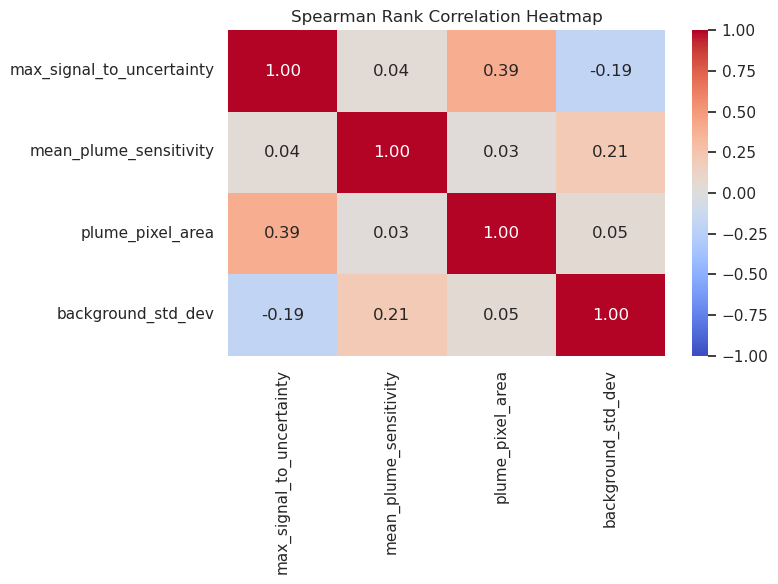

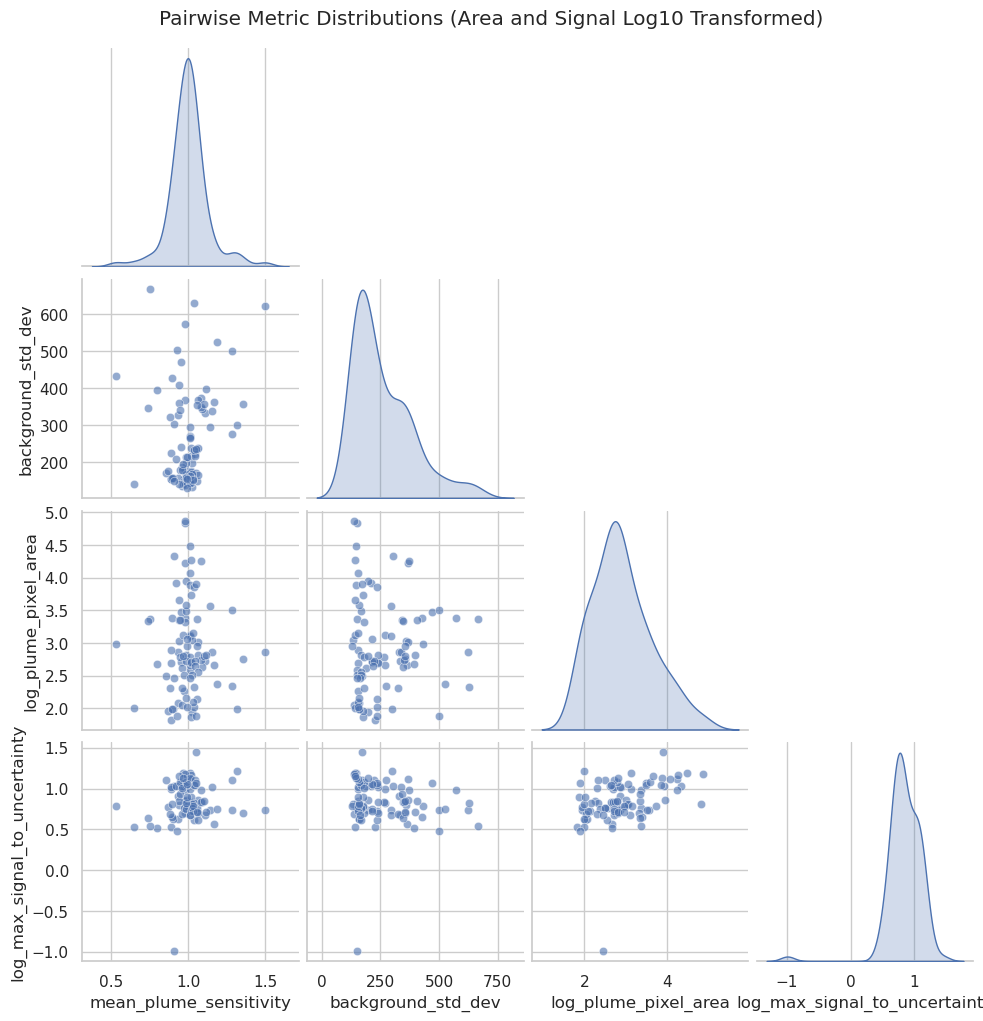

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def analyze_plume_metrics(csv_path):
    # Load the dataset
    df = pd.read_csv(csv_path)
    
    # Define the four core metrics
    metrics = [
        "max_signal_to_uncertainty", 
        "mean_plume_sensitivity", 
        "plume_pixel_area", 
        "background_std_dev"
    ]
    
    # Ensure all metrics exist in the CSV
    missing_cols = [m for m in metrics if m not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing expected columns in CSV: {missing_cols}")
        
    # Drop rows where any of the core metrics are NaN (e.g., the corrupted scenes)
    clean_df = df.dropna(subset=metrics).copy()
    print(f"Analyzing {len(clean_df)} valid plumes out of {len(df)} total rows.\n")
    
    # 1. Calculate Quartile Thresholds for the 256-bin system
    print("--- Quartile Thresholds (Bin Edges) ---")
    quartiles = clean_df[metrics].quantile([0.25, 0.50, 0.75])
    print(quartiles.to_string())
    print("\n")
    
    # 2. Pearson Correlation (Linear)
    print("--- Pearson Correlation Matrix ---")
    pearson_corr = clean_df[metrics].corr(method='pearson')
    print(pearson_corr.to_string())
    print("\n")
    
    # 3. Spearman Rank Correlation (Non-parametric, best for heavy-tailed datasets)
    print("--- Spearman Rank Correlation Matrix ---")
    spearman_corr = clean_df[metrics].corr(method='spearman')
    print(spearman_corr.to_string())
    print("\n")
    
    # 4. Generate Visualizations
    sns.set_theme(style="whitegrid")
    
    # Plot A: Correlation Heatmap (using Spearman)
    plt.figure(figsize=(8, 6))
    sns.heatmap(spearman_corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
    plt.title("Spearman Rank Correlation Heatmap")
    plt.tight_layout()
    plt.savefig("metric_correlation_heatmap.png")
    plt.show()
    
    # Plot B: Pairwise Scatter Plots with KDE diagonal
    # Log-transform Area and Signal-to-Uncertainty for visual clarity due to massive outliers
    plot_df = clean_df[metrics].copy()
    plot_df['log_plume_pixel_area'] = np.log10(plot_df['plume_pixel_area'])
    plot_df['log_max_signal_to_uncertainty'] = np.log10(plot_df['max_signal_to_uncertainty'])
    
    # Drop the unlogged versions for the plot to avoid clutter
    plot_df = plot_df.drop(columns=['plume_pixel_area', 'max_signal_to_uncertainty'])
    
    pairplot = sns.pairplot(plot_df, corner=True, diag_kind="kde", plot_kws={'alpha': 0.6})
    pairplot.fig.suptitle("Pairwise Metric Distributions (Area and Signal Log10 Transformed)", y=1.02)
    plt.savefig("metric_pairplot.png")
    plt.show()

if __name__ == "__main__":
    # Replace with your actual CSV file name
    analyze_plume_metrics("ch4_plume_stats_sample_100.csv")

Analyzing 98 valid plumes out of 100 total rows.

--- Quartile Thresholds (Bin Edges) ---
      max_signal_to_uncertainty  mean_plume_sensitivity  plume_pixel_area  background_std_dev
0.25                    5.48349                0.881697            546.75             9363.35
0.5                     6.77979                 1.04068            1366.5             11912.3
0.75                    8.46121                 1.12888           3501.75               14599


--- Pearson Correlation Matrix ---
                           max_signal_to_uncertainty  mean_plume_sensitivity  plume_pixel_area  background_std_dev
max_signal_to_uncertainty                          1                 0.53114         0.0316217            0.522613
mean_plume_sensitivity                       0.53114                       1         0.0119757            0.381458
plume_pixel_area                           0.0316217               0.0119757                 1          -0.0653287
background_std_dev                   

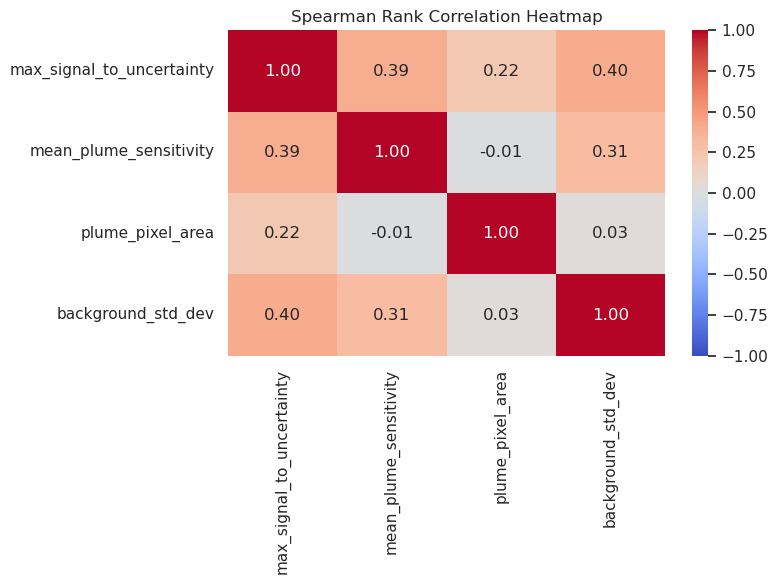

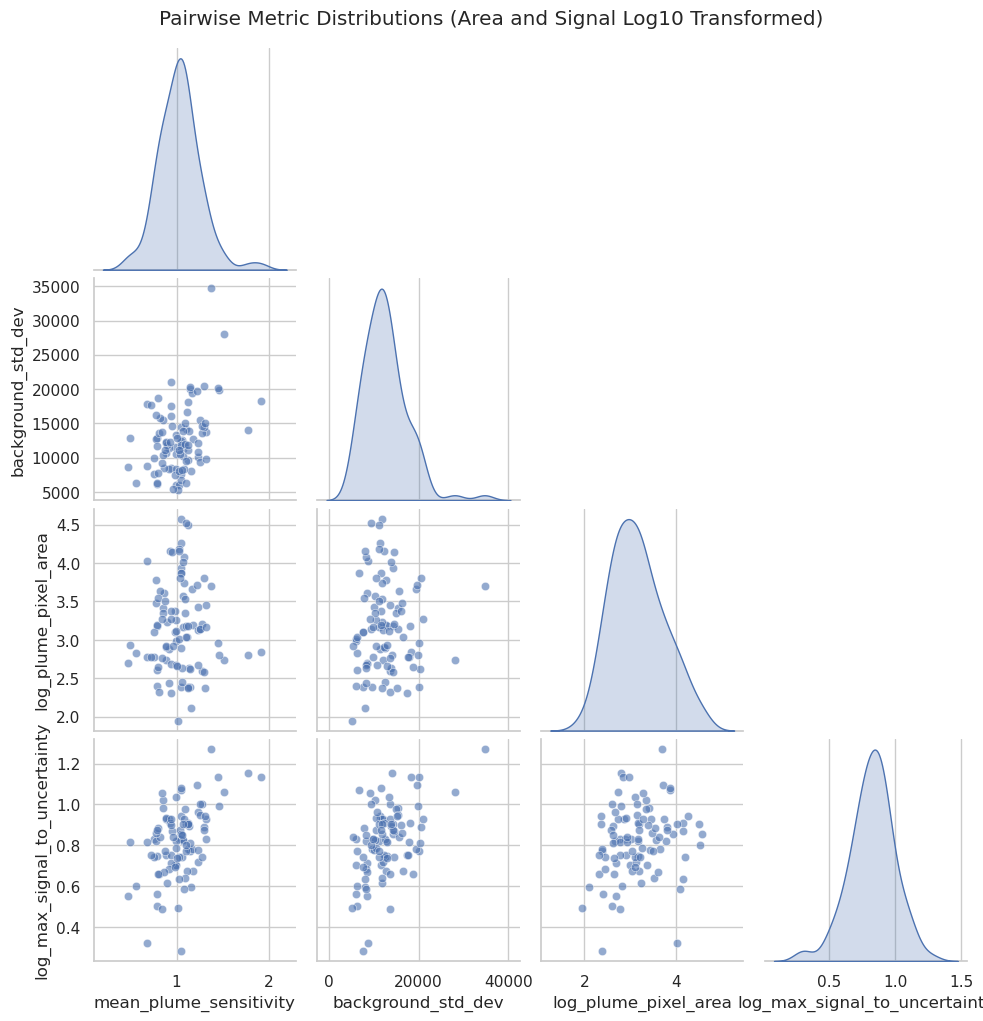

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def analyze_plume_metrics(csv_path):
    # Load the dataset
    df = pd.read_csv(csv_path)
    
    # Define the four core metrics
    metrics = [
        "max_signal_to_uncertainty", 
        "mean_plume_sensitivity", 
        "plume_pixel_area", 
        "background_std_dev"
    ]
    
    # Ensure all metrics exist in the CSV
    missing_cols = [m for m in metrics if m not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing expected columns in CSV: {missing_cols}")
        
    # Drop rows where any of the core metrics are NaN (e.g., the corrupted scenes)
    clean_df = df.dropna(subset=metrics).copy()
    print(f"Analyzing {len(clean_df)} valid plumes out of {len(df)} total rows.\n")
    
    # 1. Calculate Quartile Thresholds for the 256-bin system
    print("--- Quartile Thresholds (Bin Edges) ---")
    quartiles = clean_df[metrics].quantile([0.25, 0.50, 0.75])
    print(quartiles.to_string())
    print("\n")
    
    # 2. Pearson Correlation (Linear)
    print("--- Pearson Correlation Matrix ---")
    pearson_corr = clean_df[metrics].corr(method='pearson')
    print(pearson_corr.to_string())
    print("\n")
    
    # 3. Spearman Rank Correlation (Non-parametric, best for heavy-tailed datasets)
    print("--- Spearman Rank Correlation Matrix ---")
    spearman_corr = clean_df[metrics].corr(method='spearman')
    print(spearman_corr.to_string())
    print("\n")
    
    # 4. Generate Visualizations
    sns.set_theme(style="whitegrid")
    
    # Plot A: Correlation Heatmap (using Spearman)
    plt.figure(figsize=(8, 6))
    sns.heatmap(spearman_corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
    plt.title("Spearman Rank Correlation Heatmap")
    plt.tight_layout()
    plt.savefig("metric_correlation_heatmap.png")
    plt.show()
    
    # Plot B: Pairwise Scatter Plots with KDE diagonal
    # Log-transform Area and Signal-to-Uncertainty for visual clarity due to massive outliers
    plot_df = clean_df[metrics].copy()
    plot_df['log_plume_pixel_area'] = np.log10(plot_df['plume_pixel_area'])
    plot_df['log_max_signal_to_uncertainty'] = np.log10(plot_df['max_signal_to_uncertainty'])
    
    # Drop the unlogged versions for the plot to avoid clutter
    plot_df = plot_df.drop(columns=['plume_pixel_area', 'max_signal_to_uncertainty'])
    
    pairplot = sns.pairplot(plot_df, corner=True, diag_kind="kde", plot_kws={'alpha': 0.6})
    pairplot.fig.suptitle("Pairwise Metric Distributions (Area and Signal Log10 Transformed)", y=1.02)
    plt.savefig("metric_pairplot.png")
    plt.show()

if __name__ == "__main__":
    # Replace with your actual CSV file name
    analyze_plume_metrics("co2_plume_stats_sample_100.csv")